In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Homework \#2


The goal of this homework is to provide practice examples for applications of concentration inequalities in determining confidence intervals.

## Problem 1: Empirical Estimate of Variance

In the discussion session you saw how to estimate variance from bounded data samples when the true mean is known. In this question, you are asked to estimate the variance in the same setting, but *without knowing the true mean.* The precise problem statement is:

Suppose you are given access to i.i.d. samples $X_1, X_2, \dots, X_n$ that are guaranteed to come from a probability distribution such that $X_i \in [a, b]$ surely, for all $i \in \{1, \dots, n\}$, where $a < b$ are real numbers. 

Let $\bar{\mu} = \frac{1}{n}\sum_{i=1}^n X_i$ be the empirical estimate of the mean and $\bar{\sigma}^2 = \frac{1}{n}\sum_{i=1}^n (X_i - \bar{\mu})^2$ be the empirical estimate of the variance. Given a confidence parameter $\delta \in (0, 1)$ and $n$ (the number of samples), provide a symmetric confidence interval for your variance estimate (that is, find $\epsilon > 0$ such that your variance estimate is within $\pm \epsilon$ of the true variance with probability at least $1 - \delta$). Justify your answer.

Code a function in Python that takes $a, b, n, \delta$ as input and returns $\epsilon$ from your answer above.

**Hint:** One way of approaching this question is as follows: if you knew the mean $\mu$, then you could apply the appropriate concentration bound to estimate the variance, using $\hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^n (X_i - {\mu})^2$. You also know how to estimate $\mu$ using the appropriate concentration inequality. A key observation here is that $|\bar{\sigma}^2 - \sigma^2| \leq |\bar{\sigma}^2 - \hat{\sigma}^2| + |\hat{\sigma}^2 - \sigma^2|$ and so $\mathbb{P}[|\bar{\sigma}^2 - \sigma^2| > t] \leq \mathbb{P}[|\bar{\sigma}^2 - \hat{\sigma}^2| + |\hat{\sigma}^2 - \sigma^2| \geq t],$ for any $t > 0$ (why?). You can reason about an upper bound on $\mathbb{P}[|\bar{\sigma}^2 - \hat{\sigma}^2| + |\hat{\sigma}^2 - \sigma^2| \geq t]$ by noticing that $|\bar{\sigma}^2 - \hat{\sigma}^2| + |\hat{\sigma}^2 - \sigma^2| \geq t$ implies that $|\bar{\sigma}^2 - \hat{\sigma}^2| \geq t/2$ or $|\hat{\sigma}^2 - \sigma^2| \geq t/2$ (or both).  

## Solution for Problem 1:

First, notice that $\mathbb{P}[\vert \bar{\sigma}^2 - \sigma^2 \vert > t \leq \mathbb{P}[\vert \bar{\sigma}^2 - \hat{\sigma}^2 \vert \geq \frac{t}{2}] + \mathbb{P}[\vert \hat{\sigma}^2 - \sigma^2 \vert \geq \frac{t}{2}]$ by the implication from the hint. We will first examine 
$\mathbb{P}[\vert \hat{\sigma}^2 - \sigma^2 \vert \geq \frac{t}{2}]$ by defining $Y_i = (X_i - \mu)^2$ with $\mathbb{E}[Y_i] = \sigma^2$ by definition of variance. Notice that $\hat{\sigma} = \frac{1}{n}\sum_{i=1}^n Y_i = \mu_{Y_i}$ so we have both the empirical and true mean of $Y_i$, thus by the Hoeffding bound 
$$\mathbb{P}[\vert \hat{\sigma}^2 - \sigma^2 \vert \geq \frac{t}{2}] \leq 2e^{\frac{-nt^2}{2(a-b)^4}} = \frac{\delta}{2}$$
since $Y_i \in [0, (b-a)^2]$. Solving for $t$ gives $$t = \epsilon_1 = \sqrt{\frac{(b-a)^4 \ln(\delta/4))}{-2n}}.$$
For $\mathbb{P}[\vert \bar{\sigma}^2 - \hat{\sigma}^2 \vert \geq \frac{t}{2}]$, we can expand 
\begin{align} \bar{\sigma}^2 &= \frac{1}{n} \sum_{i = 1}^{n}(X_i - \mu + \mu - \hat{\mu})^2\\
&= \frac{1}{n}\sum_{i=1}^n (X_i - \mu)^2 + 2(X_i-\mu)(\mu-\bar{\mu}) + (\mu-\bar{\mu})^2\\
&= \hat{\sigma}^2 + (\mu - \bar{\mu})^2 + 2(\mu-\bar{\mu})\frac{1}{n}\sum_{i=1}^n (X_i - \mu)\\
&= \hat{\sigma}^2 + (\mu - \bar{\mu})^2 -2(\mu-\bar{\mu})(\mu+\bar{\mu})\\
&= \hat{\sigma}^2 - (\mu - \bar{\mu})^2.
\end{align}
By substitution, $\mathbb{P}[\bar{\vert \sigma}^2 - \hat{\sigma}^2\vert \geq \frac{t}{2}] = \mathbb{P}[\vert \mu - \bar{\mu}\vert \geq \sqrt{\frac{t}{2}}]$. Then the Hoeffding bound shows $\mathbb{P}[\vert \mu - \bar{\mu}\vert \geq \sqrt{\frac{t}{2}}] \leq 2e^{\frac{-nt}{(b-a)^2}}$ and solving for $t$ gives $$t = \epsilon_2 = \frac{(b-a)^2 \ln(\frac{\delta}{4})}{-n}$$. So for $\epsilon = \epsilon_1 + \epsilon_2$ then $\mathbb{P}[\vert\hat{\sigma}^2 - \sigma^2\vert > \epsilon] <\delta$ or equivalently $\mathbb{P}[\vert\hat{\sigma}^2 - \sigma^2\vert \leq \epsilon] \leq 1 - \delta.$

In [2]:
import math

def calculate_epsilon(a, b, n, delta):
    e1_numerator = (b-a)**4 * math.log(delta/4)
    epsilon1 = math.sqrt(e1_numerator/(-n))

    epsilon2 = ((b-a)**2*math.log(delta/4))/(-n)
    return epsilon1 + epsilon2

epsilon = calculate_epsilon(0,1, 1000, 0.00004)
print(epsilon)

0.11881122677943759


## Problem 2: Madison Metro buses keep getting delayed

A campus bus line claims each trip is on time with probability $p=0.9$, independently across trips. An enthusiastic fan of Madison Metro who nonetheless keeps getting delayed sets out to investigate this and collects some data. She observes out of $N=50$ trips, only $x=36$ are on time.

Let $X$ be the number of on-time trips among the 50.

1. Under the claim $p=0.9$, compute the exact probabilities $\mathbb{P}(X=36)$ and $\mathbb{P}(X\le 36)$.
2. Use Chebyshev’s inequality to upper-bound $\mathbb{P}(X\le 36)$.
3. Use the basic Hoeffding bound to upper-bound $\mathbb{P}(X\le 36)$.
4. Based on these numbers, would you be suspicious of the claim $p=0.9$?


## Solution for Problem 2:

1. $\mathbb{P}(X = 36) = \binom{50}{36}(0.9^{36})(0.1^{14}) = 0.000211$ since $X$ is a random binomial variable. Similarly $\mathbb{P}(X\leq 36) = \sum_{k=0}^{50} \binom{50}{k}(0.9^k)(0.1^{50-k}) = 0.000285$.
2. Using Chebyshev's inequality, note that $\mu = 50p = 45$ and $\sigma^2 = 50*0.5*0.1 = 4.5$. Since $\vert 36 - 35 \vert = 9$ then $\mathbb{P}(X \leq 36) \leq \mathbb{P}(\vert 36 - \mu \vert \geq 9) \leq \frac{4.5}{81} \approx 0.0056$
3. First, since $X \in \{0,1\}$ with $\mathbb{E}(X) = 0.9$ let $Y = X - 0.9$ which gives $\mathbb{E} = 0$ and we can apply Hoeffding bound by the Hoeffding Lemma. Then because $Y$ is $\frac{1}{4}$-subgaussian, $\mathbb{P}(Y - 36 \geq -9) = \mathbb{P}(\frac{Y}{50} - \frac{36}{50} \geq \frac{-9}{50}) \leq e^{-2*50 \frac{9}{50}^2} = 0.039.$
4. Given that the difference between the Hoeffding bound and Chebyshev upper bound isn't even within a magnitude of 10, I am suspicious that the true probability is $p = 0.9$ because the concentration inequalities haven't shown anything concrete given their lack of tightness.

## Problem 3: Dining Hall Wait Times

You are studying wait times at 4 UW-Madison dining halls. For dining hall $h\in\{1,2,3,4\}$, let $X_{h,i}$ be the wait time (in minutes) for the $i$-th randomly selected student at that hall.

Assume:
- The samples are random and independent.
- Wait times are bounded: $0 \le X_{h,i} \le 30$ for all $h,i$.

For each hall $h$, you want to estimate two quantities:
1) the mean wait time $\mu_h = \mathbb{E}[X_{h,i}]$,

2) the “long wait” proportion $q_h = \mathbb{P}(X_{h,i} > 20)$.

You will use:
- the sample mean $\bar X_h$ to estimate $\mu_h$,
- the sample proportion $\hat q_h = \frac{1}{n}\sum_{i=1}^n \mathbf{1}\{X_{h,i}>20\}$ to estimate $q_h$,

using the same number $n$ of samples per dining hall.

How large should $n$ be so that with probability at least $0.99$,
- for every hall $h$, $|\bar X_h - \mu_h| \le 1$ (mean within $\pm 1$ minute), and
- for every hall $h$, $|\hat q_h - q_h| \le 0.02$ (proportion within $\pm 2\%$)

both hold simultaneously?


## Solution for Problem 3:

We can use Hoeffding bound on $\bar{X}_h$ such that $\mathbb{P}[\vert\bar{X}_h - \mu_h\vert \geq 1] \leq 2e^{\frac{-2n}{900}}$ for each $i \in h$. Notice that by construction, $\hat{q}^h$ is a sample mean in itself so we can apply Hoeffding bound similarly such that $\mathbb{P}[\vert \hat{q}_h - q_h \vert \geq 0.02] \leq 2e^{-2n(0.02)^2}$. Since there's 4 dining halls then that gives 8 total failure cases (1 for each estimated sample mean and sample proportion). By union bound and substitution,
$$\mathbb{P}[\text{at least 1 case fails}] \leq 4\mathbb{P}[\vert\bar{X}_h - \mu_h\vert \geq 1] + 4\mathbb{P}[\vert \hat{q}_h - q_h \vert \geq 0.02] \leq 8e^{\frac{-2n}{900}} + 8e^{-2n(0.02)^2}.$$
Since $\frac{2}{900}>0.0008$ then solve for $n$ on $e^{-2n(0.02)^2}= \frac{0.01}{16}$ which gives $n = 9223$.

## Problem 4: Gaussian Random Variables are Likely to be on a Hypercube

Let $\mathbf{x}$ be a vector that is drawn from a unit $d$-dimensional sphere according to a uniform distribution. You are asked to prove in this question that all coordinates of $\mathbf{x}$ are likely to be of the order $\pm \frac{1}{\sqrt{d}}.$ **Some hints:** (1) random vector $\mathbf{z}/\|\mathbf{z}\|_2$ for $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ is uniformly distributed on the unit sphere, (2) consider conditioning on the event $\mathcal{E} = \{\|\mathbf{z}\|_2 \leq \sqrt{d/2}\}$ and its complement, as we did in the proof of the Lemma "Near-orthogonality of Gaussian vectors in high dimensions" in Lecture 3, (3) observe that the coordinate $i$ of $\mathbf{z},$ denoted by $z_i$, satisfies $z_i = \mathbf{z}^\top \mathbf{e}_i,$ where $\mathbf{e}_i$ is the $i$-th standard basis vector. The result you should get is that for $t \lesssim \sqrt{d}$, $\mathbb{P}[|x_i| \geq t/\sqrt{d}] \leq c_1 e^{- c_2 t^2},$ where $c_1$ and $c_2$ are absolute constants (i.e., numbers like 4 and 1/4 $-$ the exact values do not matter as long as they do not depend on the dimension and your approach is correct).  

## Solution for Problem 4:

Let $\mathbf{x} = \frac{\mathbf{z}}{\|\mathbf{z}\|_2}$ and note that $x_i = \frac{z_i}{\|\mathbf{z}\|_2}$. Define event $\mathcal{E} = \{\|\mathbf{z}\|_2 \leq \sqrt{\frac{d}{2}}\}$ and $\mathcal{E}^c = \{\| \mathbf{z} \|_2 > \sqrt{\frac{d}{2}}\}$. Then we can decompose 
\begin{align}
\mathbb{P}[\vert x_i \vert \geq \frac{t}{\sqrt{d}}] &= \mathbb{P}[\vert \frac{z_i}{\|\mathbf{z}\|_2} \vert \geq \frac{t}{\sqrt{d}}]\\
&\leq \mathbb{P}[\frac{z_i}{\|\mathbf{z}\|_2} \geq \frac{t}{\sqrt{d}} \vert \mathcal{E}^c] + \mathbb{P}[\mathcal{E}]
\end{align}
by bounding $\mathbb{P}[\mathcal{E}^c] \leq 1$ and $\mathbb{P}[\vert z_i \vert \geq \frac{\|\mathbf{z}\|_2 t}{\sqrt{d}} \vert \mathcal{E}] \leq 1$ which is trivial because $\|\mathbf{z}\| = 1$. Observe then that 
$$\vert z_i\vert \geq \frac{t}{\sqrt{d}} > \frac{t\|\mathbf{z}\|_2}{\sqrt{d}} \sqrt{\frac{d}{2}} = \frac{t}{\sqrt{2}}$$
thus, $\mathbb{P}[\vert z_i \vert \geq \frac{t}{\sqrt{2}}] \leq 2e^{\frac{-t^2}{4}}$ by Lemma 2 in the high dimensional geometry notes. Next, notice 
$$\mathbb{P}[\mathcal{E}] = \mathbb{P}[\|\mathbf{z}\|_2 \leq \sqrt{\frac{d}{2}}] = e^\frac{-d}{16}$$
by a consequence of the Gaussian Annulus Theorem. Then we have that 
$$ \mathbb{P}[\vert x_i \vert \geq \frac{t}{\sqrt{d}}] = 2e^{\frac{-t^2}{4}} + e^\frac{-d}{16}.$$
If $t \lesssim \sqrt{d}$ then $t^2 \leq c_2d$ for all positive $c_2 < 1$. By substitution, $e^{-d}{16c_2} \geq e^{-t^2}{16}$. By substitution, 
$$ \mathbb{P}[\vert x_i \vert \geq \frac{t}{\sqrt{d}}] \leq 2e^{\frac{-t^2}{4}} + e^{-t^2}{4} = 3e^{\frac{-t^2}{4}}$$
when $c_2 = \frac{1}{4}$ or more generally, $c_1 e^{\frac{-t^2}{16c_2}}$ for the constants $c_1 = 3$ and $c_2 = \frac{1}{4}$.

**[Coding]** Implement a function in Python that takes the dimension $d$ and the number of samples $n$ as input and displays a histogram corresponding to the empirical distribution of the values of coodinates of $n$ vectors drawn from a unit $d$-dimensional sphere uniformly at random.

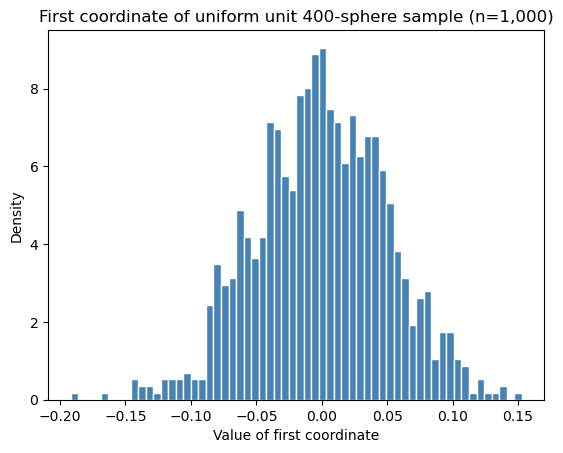

In [31]:
d = 400
n = 1000
def coordinate_histogram(d, n): 
    Z = np.random.randn(n, d)
    X = Z / np.linalg.norm(Z, axis=1, keepdims=True)

    #sufficient to use first coordinate by definition of gaussian vector
    plt.hist(X[:, 0], bins=60, density=True, color="steelblue", edgecolor="white")
    plt.xlabel("Value of first coordinate")
    plt.ylabel("Density")
    plt.title(f"First coordinate of uniform unit {d}-sphere sample (n={n:,})")
    plt.show()
     
coordinate_histogram(d, n)